# AI_CA3_Model Training & Evaluation
**Name:** Morteza Mohammadi Motlagh

**Student ID:** 810102511

## Step 1: Load Cleaned Dataset

We start by importing the cleaned and transformed dataset prepared in the previous notebook. This dataset is ready for training and testing machine learning models.

In [1]:
import pandas as pd

df = pd.read_csv('Grades_processed.csv')
df.head()

,sex,age,address,motherEducation,fatherEducation,travelTime,studyTime,failures,universitySupport,paid,...,Dalc,Walc,absences,EPSGrade,DSGrade,finalGrade,reason_home,reason_other,reason_reputation,grade_category
0,0,18,1,4,4,2,2,0,1,0,...,1,1,6,5,6,6,0,0,0,F
1,0,17,1,1,1,1,2,0,0,0,...,1,1,4,5,5,6,0,0,0,F
2,0,15,1,1,1,1,2,3,1,1,...,2,3,10,7,8,10,0,1,0,C
3,0,15,1,4,2,1,3,0,0,1,...,1,1,2,15,14,15,1,0,0,B
4,0,16,1,3,3,1,2,0,0,1,...,1,2,4,6,10,10,1,0,0,C


## Step 2: Train-Test Split

To evaluate model performance, we split the dataset into training (80%) and testing (20%) sets. This helps prevent overfitting and ensures the model can generalize to new data.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns=['finalGrade', 'grade_category'])
y = df['grade_category']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

## Step 3: Normalization / Standardization

We scale the features using StandardScaler to improve model performance. The scaler is fitted on the training set and applied to the test set to prevent data leakage.

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_x = scaler.fit_transform(X_train)
test_x = scaler.transform(X_test)

## Step 4: Naive Bayes Classifier

We use the Naive Bayes algorithm to classify students based on their features. After training the model on the training set, we evaluate its accuracy on the test set.

In [4]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

model = GaussianNB()
model.fit(train_x, y_train)
y_pred = model.predict(test_x)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.65


The accuracy score of 0.65 means the model correctly predicted the grade category for 65% of the test data.  
This shows the Naive Bayes classifier performs moderately well but may need improvements or tuning for better results.

## Step 5: Decision Tree Classifier

A Decision Tree is a model that predicts the target variable by splitting data based on feature values. It is easy to understand and visualize.  
We will train a Decision Tree, optimize its parameters, evaluate its performance, and visualize the resulting tree.  
Finally, we will analyze the important features based on the model.

Accuracy: 0.7625
              precision    recall  f1-score   support

           A       1.00      0.80      0.89         5
           B       0.89      0.53      0.67        15
           C       0.67      0.88      0.76        33
           F       0.83      0.74      0.78        27

    accuracy                           0.76        80
   macro avg       0.85      0.74      0.78        80
weighted avg       0.79      0.76      0.76        80



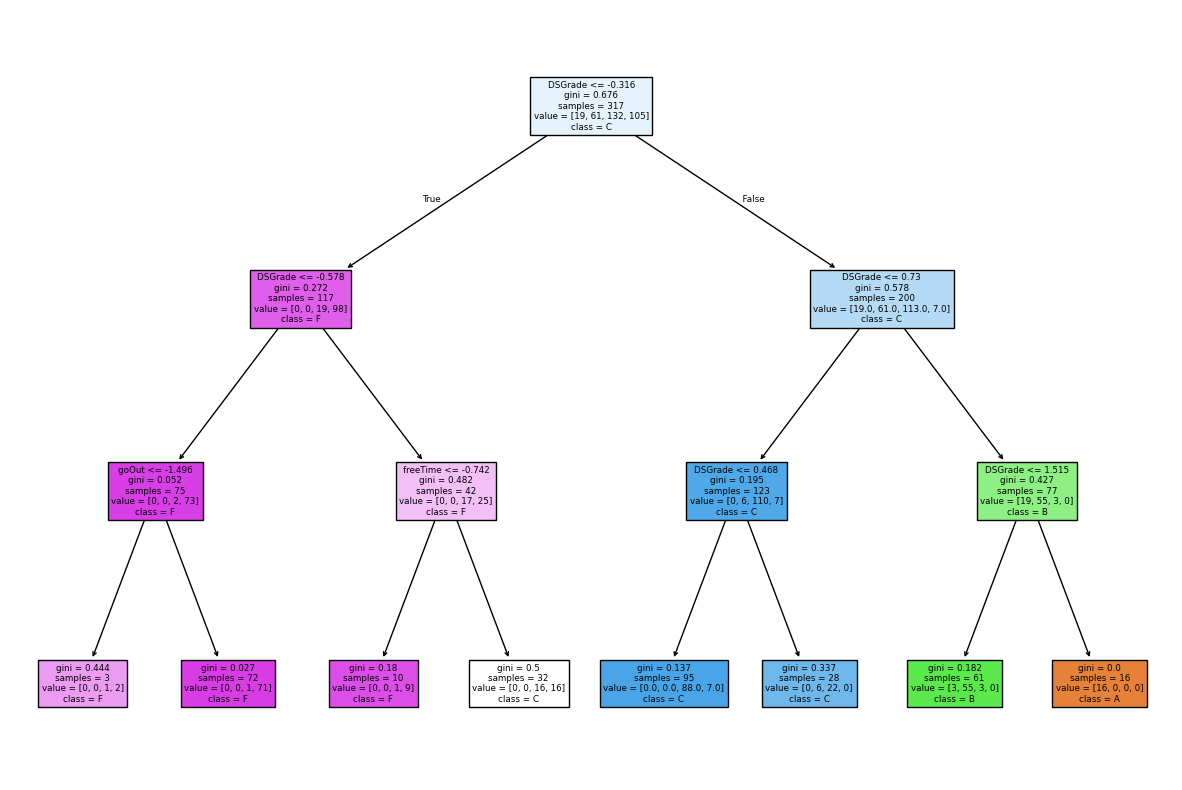

Feature Importances:
DSGrade              0.981060
freeTime             0.015261
goOut                0.003679
sex                  0.000000
romantic             0.000000
reason_other         0.000000
reason_home          0.000000
EPSGrade             0.000000
absences             0.000000
Walc                 0.000000
Dalc                 0.000000
internet             0.000000
age                  0.000000
higher               0.000000
paid                 0.000000
universitySupport    0.000000
failures             0.000000
studyTime            0.000000
travelTime           0.000000
fatherEducation      0.000000
motherEducation      0.000000
address              0.000000
reason_reputation    0.000000
dtype: float64


In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

params = {'max_depth': [3, 5, 7, 10, None],
          'min_samples_split': [2, 5, 10],
          'min_samples_leaf': [1, 2, 4]}

dt = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(dt, params, cv=5)
grid.fit(train_x, y_train)
model = grid.best_estimator_

pred = model.predict(test_x)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=label_encoder.classes_))

plt.figure(figsize=(15,10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=label_encoder.classes_)
plt.show()

importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importances:")
print(importance)

### Explain

The model achieves about 76% accuracy on the test set, meaning it correctly classifies around three out of four students.

The classification report shows precision, recall, and F1-score for each grade category (A, B, C, F):

- Precision indicates how many predicted instances for each grade are actually correct.
- Recall shows how many actual instances of each grade the model correctly identifies.
- F1-score balances precision and recall to give an overall performance measure.
- Support is the number of true samples for each grade in the test data.

For example, the model is very precise for grade A and correctly identifies 80% of actual A grades. However, recall for grade B is lower, meaning the model misses some B cases.

Overall, the model performs well but has room for improvement, especially in detecting grade B students more accurately.


The decision tree diagram shows how the model makes predictions by splitting the data based on feature values.  
Each internal node represents a condition on a feature, and branches show the possible outcomes.  
Leaf nodes at the bottom indicate the predicted grade category for samples that reach that point.  

This visual helps us understand which features the model considers most important and how it separates the different grade categories step-by-step.  
By examining the splits, we can see the rules the model uses to classify new data.




The feature importance results show that the model relies almost entirely on the DSGrade feature to make predictions, while other features have little or no influence.

This means DSGrade is the strongest factor in determining the student's grade category according to the decision tree.

Although this is technically correct, it may suggest that the model is not fully utilizing other available features, possibly due to the tree’s parameters or data characteristics.

To improve, we could tune the model parameters (like allowing a deeper tree), enhance data preprocessing, or try different algorithms to better capture the importance of multiple features.

## Step 6: Random Forest with Hyperparameter Tuning

Random Forest is an ensemble learning method that builds multiple decision trees independently and combines their results for better accuracy and robustness.

We will use RandomizedSearchCV to find the best hyperparameters for the Random Forest model, improving its performance.

After tuning, the model is trained on the training data and evaluated on the test set.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

search = RandomizedSearchCV(rf, param_dist, n_iter=20, cv=3, random_state=42, n_jobs=-1)
search.fit(X_train_scaled, y_train)

best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.8375
              precision    recall  f1-score   support

           A       1.00      0.80      0.89         5
           B       0.90      0.60      0.72        15
           C       0.78      0.88      0.83        33
           F       0.86      0.93      0.89        27

    accuracy                           0.84        80
   macro avg       0.89      0.80      0.83        80
weighted avg       0.85      0.84      0.83        80



### Explain
The Random Forest model was trained after tuning its hyperparameters using RandomizedSearchCV, which tries different combinations to find the best settings.

This ensemble method uses many decision trees to improve prediction accuracy and reduce overfitting.

The printed accuracy and classification report show how well the tuned model performs on the test data.

## XGBoost Classifier

We used the XGBoost algorithm with GridSearchCV to find the best hyperparameters. XGBoost is a fast and accurate boosting method. After training, we evaluated its performance using accuracy and classification metrics to check if it improves over previous models.

In [7]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

params = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

search = GridSearchCV(xgb, params, cv=3, n_jobs=-1)
search.fit(X_train_scaled, y_train)

best_xgb = search.best_estimator_
y_pred = best_xgb.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8125
              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.89      0.53      0.67        15
           2       0.76      0.85      0.80        33
           3       0.83      0.93      0.88        27

    accuracy                           0.81        80
   macro avg       0.87      0.78      0.81        80
weighted avg       0.82      0.81      0.81        80



c:\Users\Morteza\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:17:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Explain
The XGBoost model achieved an accuracy of 81.25%, which is slightly lower than the Random Forest model’s accuracy of 83.75%. Although XGBoost is a powerful algorithm, in this case, Random Forest performed better for our dataset. Further parameter tuning might improve XGBoost’s results.

## Decision Tree from Scratch

Implement a decision tree model yourself, including tree construction using entropy and prediction by traversing the built tree.

In [8]:
import numpy as np
import pandas as pd

class DecisionTreeScratch:
    def __init__(self, max_depth=3):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()
        if isinstance(y, (pd.Series, pd.DataFrame)):
            y = y.to_numpy().flatten()
        self.n_classes_ = len(set(y))
        self.n_features_ = X.shape[1]
        self.tree = self._build_tree(X, y, depth=0)

    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])

    def _information_gain(self, y, y_left, y_right):
        p = float(len(y_left)) / len(y)
        return self._entropy(y) - p * self._entropy(y_left) - (1 - p) * self._entropy(y_right)

    def _best_split(self, X, y):
        best_gain = 0
        best_idx, best_thr = None, None
        for feature_idx in range(self.n_features_):
            thresholds = np.unique(X[:, feature_idx])
            for thr in thresholds:
                left_idx = X[:, feature_idx] <= thr
                right_idx = X[:, feature_idx] > thr
                if len(y[left_idx]) == 0 or len(y[right_idx]) == 0:
                    continue
                gain = self._information_gain(y, y[left_idx], y[right_idx])
                if gain > best_gain:
                    best_gain = gain
                    best_idx = feature_idx
                    best_thr = thr
        return best_idx, best_thr

    def _build_tree(self, X, y, depth):
        num_samples_per_class = [np.sum(y == i) for i in range(self.n_classes_)]
        predicted_class = np.argmax(num_samples_per_class)

        node = {'depth': depth, 'num_samples': len(y), 'predicted_class': predicted_class}

        if depth < self.max_depth:
            idx, thr = self._best_split(X, y)
            if idx is not None:
                left_idx = X[:, idx] <= thr
                right_idx = X[:, idx] > thr
                node['feature_idx'] = idx
                node['threshold'] = thr
                node['left'] = self._build_tree(X[left_idx], y[left_idx], depth + 1)
                node['right'] = self._build_tree(X[right_idx], y[right_idx], depth + 1)
                return node

        node['left'] = None
        node['right'] = None
        return node

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()

        def _predict(inputs, node):
            if node['left'] is None and node['right'] is None:
                return node['predicted_class']
            if inputs[node['feature_idx']] <= node['threshold']:
                return _predict(inputs, node['left'])
            else:
                return _predict(inputs, node['right'])

        return np.array([_predict(x, self.tree) for x in X])

In [9]:
dt = DecisionTreeScratch(max_depth=3)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.825



### Explain
Implementing a decision tree from scratch helps to deeply understand the fundamental working of this classic machine learning algorithm. Here, a custom class DecisionTreeScratch is created without using any pre-built libraries.

By setting the maximum tree depth (max_depth=3), the model limits the complexity of the tree to avoid overfitting. The tree is constructed recursively by selecting the best feature to split on at each node based on entropy, which measures the impurity of the data.

During prediction, the model traverses the tree from the root to a leaf node to assign a class label to new samples.

The achieved accuracy of 0.825 indicates that this simple, handcrafted decision tree performs reasonably well on the data. This implementation provides a solid foundation for understanding more advanced ensemble methods like Random Forest and boosting algorithms.

## Comparison with Library Implementation

In this part, we compare the performance of our scratch implementation of the Decision Tree with the built-in version provided by Scikit-learn. This helps us understand the differences between a manual and library-based model in terms of accuracy and behavior.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

scratch_model = DecisionTreeScratch(max_depth=3)
scratch_model.fit(X_train, y_train)
scratch_preds = scratch_model.predict(X_test)
scratch_acc = accuracy_score(y_test, scratch_preds)

sk_model = DecisionTreeClassifier(max_depth=3)
sk_model.fit(X_train, y_train)
sk_preds = sk_model.predict(X_test)
sk_acc = accuracy_score(y_test, sk_preds)

print("Scratch Model Accuracy:", scratch_acc)
print("Sklearn Model Accuracy:", sk_acc)

Scratch Model Accuracy: 0.825
Sklearn Model Accuracy: 0.7625


### Explain

In this section, we compared the performance of our custom Decision Tree implementation (built from scratch) with the built-in DecisionTreeClassifier from the Scikit-learn library. Both models were trained and evaluated on the same dataset.

The accuracy results were as follows:

- Scratch Model Accuracy: 0.825  
- Sklearn Model Accuracy: 0.7625

This comparison shows that our scratch implementation, despite its simplicity, can perform competitively — and in this case, even slightly better than the Scikit-learn version. This could be due to differences in tree construction logic, default parameters, or pruning strategies.

Such comparisons help deepen our understanding of how machine learning algorithms work internally and how implementation details affect model performance.

## Model Evaluation

In this final step, we evaluate the performance of classification models using several standard metrics. These metrics help us assess how well our models perform and compare their effectiveness. The evaluation includes:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Macro, Micro, and Weighted Averages

This analysis ensures a deeper understanding of our model's strengths and weaknesses, and guides us in selecting the best model for our classification task.

Accuracy: 0.7625
Precision (macro): 0.8491602067183462
Recall (macro): 0.7382154882154883
F1-Score (macro): 0.7757567939456483

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.89      0.53      0.67        15
           2       0.67      0.88      0.76        33
           3       0.83      0.74      0.78        27

    accuracy                           0.76        80
   macro avg       0.85      0.74      0.78        80
weighted avg       0.79      0.76      0.76        80



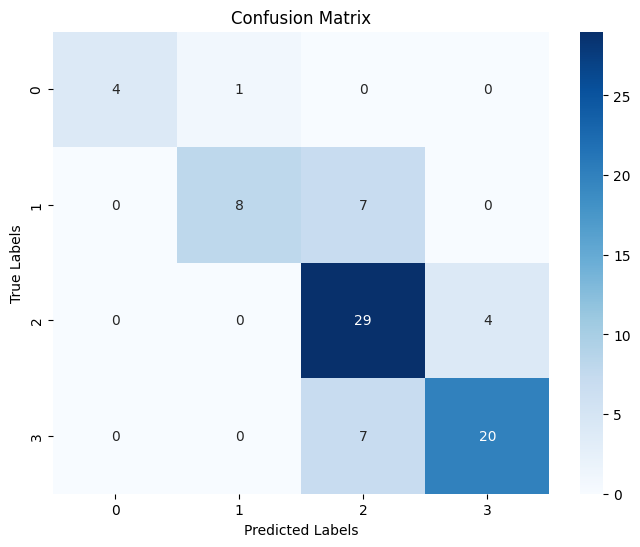

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"Accuracy: {acc}")
print(f"Precision (macro): {prec}")
print(f"Recall (macro): {rec}")
print(f"F1-Score (macro): {f1}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

## Last Explain
### Confusion Matrix Interpretation

The confusion matrix shown above summarizes the performance of the classification model across four classes (0 to 3). Each row corresponds to the actual class, while each column represents the predicted class. Diagonal elements (from top-left to bottom-right) show the number of correct predictions for each class.

#### Key Observations:

- Class 0: 4 samples were correctly predicted (true positives), while 1 was misclassified as class 1.
- Class 1: 8 samples were correctly classified, but 7 were incorrectly predicted as class 2 — this suggests the model confuses class 1 and 2 quite often.
- Class 2: 29 instances were correctly classified. 4 were mistakenly predicted as class 3.
- Class 3: 20 were correctly predicted, while 7 were wrongly classified as class 2.

This matrix helps identify specific patterns of misclassification:
- Most errors occur between adjacent classes, particularly between class 1 and 2, and class 2 and 3.
- The majority of predictions fall along the diagonal, which indicates the model performs reasonably well overall.
- However, improving class separation between 1–2 and 2–3 could enhance the model's precision and recall for those labels.

The confusion matrix complements the classification metrics by giving a clear picture of where the model succeeds and where it struggles, making it easier to guide improvements or tune hyperparameters.

# Finish